# 1.Problem Definition

# 2.Data Collection

In [1]:
from datasets import load_dataset
import os
import pandas as pd     

In [2]:
#--loading the Dataset
ds = load_dataset("nahiar/instagram_bot_detection")

df = ds['train'].to_pandas()

#os.makedirs("data",exist_ok=True)

file_path = "data/instagram_bot_detection.csv"
df.to_csv(file_path,index= False)

print("Dataset saved and stored at: ",file_path)

Dataset saved and stored at:  data/instagram_bot_detection.csv


# 3 Data Understanding & Exploration (EDA)

In [3]:
df = pd.read_csv("data/instagram_bot_detection.csv")
df.shape

(5000, 12)

In [4]:
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [5]:
df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000
mean,0.598200,0.166175,1.212800,0.036068,0.007600,20.997200,0.049600,0.227800,103.331400,5.124435e+04,481.381800,0.50000
std,0.490311,0.194733,0.890435,0.106235,0.086855,33.234706,0.217139,0.419455,377.804886,5.963749e+05,761.530132,0.50005
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+01,58.000000,0.00000
50%,1.000000,0.089193,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,1.450000e+02,242.000000,0.50000
75%,1.000000,0.300410,2.000000,0.000000,0.000000,31.250000,0.000000,0.000000,81.000000,6.960000e+02,591.000000,1.00000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.00000


In [6]:
df['fake'].value_counts()


fake
0    2500
1    2500
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           5000 non-null   int64  
 1   nums/length username  5000 non-null   float64
 2   fullname words        5000 non-null   int64  
 3   nums/length fullname  5000 non-null   float64
 4   name==username        5000 non-null   int64  
 5   description length    5000 non-null   int64  
 6   external URL          5000 non-null   int64  
 7   private               5000 non-null   int64  
 8   #posts                5000 non-null   int64  
 9   #followers            5000 non-null   int64  
 10  #follows              5000 non-null   int64  
 11  fake                  5000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 468.9 KB


In [8]:
df.isnull().sum()

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

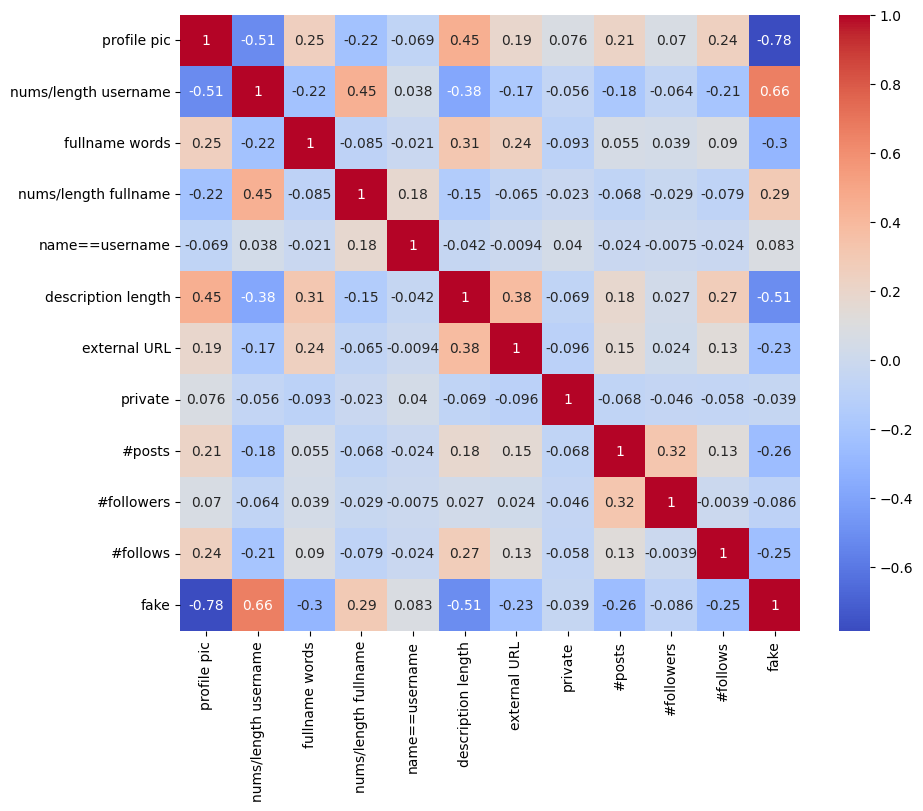

In [9]:
import seaborn as sb   
import matplotlib.pyplot as plt     

plt.figure(figsize =(10,8))
sb.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [10]:
df.groupby('profile pic')['fake'].value_counts()

profile pic  fake
0            1       1966
             0         43
1            0       2457
             1        534
Name: count, dtype: int64

# 4.Data Preprocessing

In [11]:
df.isnull().sum()

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

In [12]:
X = df.drop("fake",axis=1)
y = df['fake']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

C:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.951

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       498
           1       0.97      0.93      0.95       502

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
 [[486  12]
 [ 37 465]]


## training to RandomForestModel

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [20]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
print("Accuracy",accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy 0.989
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       498
           1       1.00      0.98      0.99       502

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [21]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 100,learning_rate = 0.1,max_depth = 5,random_state = 42)
xgb.fit(X_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
# Using the K-fold Cross Validation 
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb,X,y,cv= 5,scoring='accuracy')
print("Cross Validation Scores:",cv_scores)
print("Mean CV Accuracy:",cv_scores.mean())

Cross Validation Scores: [0.966 0.989 0.991 0.984 0.99 ]
Mean CV Accuracy: 0.984


In [23]:
from sklearn.metrics import roc_auc_score
y_prob = xgb.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,y_prob)

print("AUC score: ",auc)

AUC score:  0.9982319717115473


In [24]:
import joblib

joblib.dump(xgb,"fake_account_model.pkl")

print("Model saved successfully")

Model saved successfully


In [25]:
df.columns

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', '#posts', '#followers', '#follows', 'fake'],
      dtype='object')